In [2]:
from wav_to_embedding import * 
import tqdm

In [2]:
data_directory = "data"

wav_files = get_wav_files(data_directory)

hubert_embeddings = []
for file_path, label in tqdm.tqdm(wav_files, desc="Processing WAV files"):
    # Obtain the embedding for the current WAV file
    embedding_tensors = wav_to_embedding(file_path)
    
    # Flatten each layer's embedding and store them separately
    for layer_num, embedding_tensor in enumerate(embedding_tensors):
        embedding = embedding_tensor.detach().numpy().flatten()
        # Append the file name, label, and flattened embedding to the data list
        hubert_embeddings.append((file_path, label, layer_num, embedding))

# Convert the data list to a DataFrame
hubert_embeddings_df = pd.DataFrame(hubert_embeddings, columns=['Soundtrack', 'Label', 'Layer', 'Embedding'])

Processing WAV files: 100%|██████████████████| 762/762 [02:24<00:00,  5.29it/s]


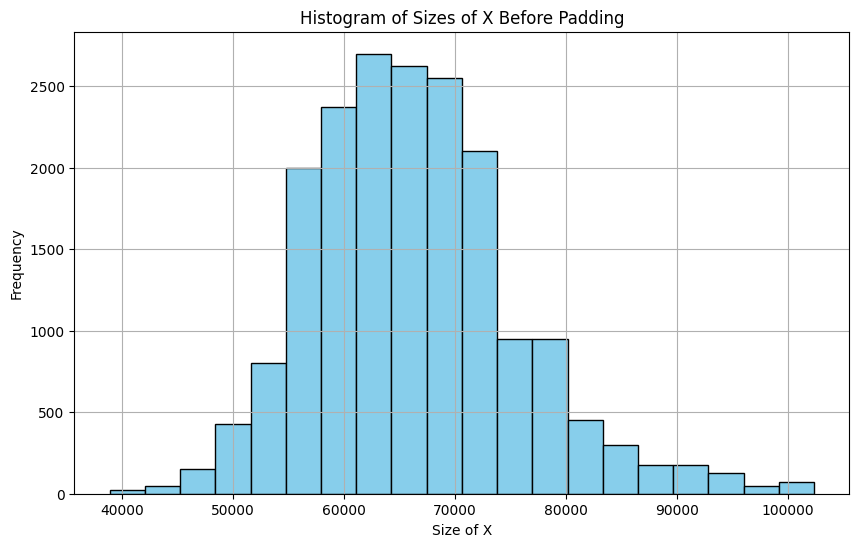

In [3]:
import matplotlib.pyplot as plt

# List to store sizes of X for each layer
sizes_before_padding = []

# Iterate through each layer
for layer_num in hubert_embeddings_df['Layer'].unique():
    # Clone the original DataFrame to preserve the original embeddings
    phonation_mode_df = hubert_embeddings_df[hubert_embeddings_df['Layer'] == layer_num].copy(deep=True)
    # Extract embeddings for the current layer
    sizes_before_padding.extend([len(embedding) for embedding in phonation_mode_df['Embedding']])

# Plotting histogram
plt.figure(figsize=(10, 6))
plt.hist(sizes_before_padding, bins=20, color='skyblue', edgecolor='black')
plt.title('Histogram of Sizes of X Before Padding')
plt.xlabel('Size of X')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


In [1]:
80000/5 #Hz

16000.0

In [4]:
len(phonation_mode_df['Embedding'][24])

60416

In [5]:
v67*1024

68608

**New embedding mean method instead of flatten**

In [3]:
data_directory = "data"

wav_files = get_wav_files(data_directory)

hubert_embeddings = []
for file_path, label in tqdm.tqdm(wav_files, desc="Processing WAV files"):
    # Obtain the embedding for the current WAV file
    embedding_tensors = wav_to_embedding(file_path)
    
    # Flatten each layer's embedding and store them separately
    for layer_num, embedding_tensor in enumerate(embedding_tensors):
        embedding = np.mean(embedding_tensors[0].detach().numpy(), axis=1)[0]
        # Append the file name, label, and flattened embedding to the data list
        hubert_embeddings.append((file_path, label, layer_num, embedding))

# Convert the data list to a DataFrame
hubert_embeddings_df = pd.DataFrame(hubert_embeddings, columns=['Soundtrack', 'Label', 'Layer', 'Embedding'])

Processing WAV files:   0%|                             | 0/762 [00:00<?, ?it/s]/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
Processing WAV files: 100%|███████████████████| 762/762 [02:15<00:00,  5.62it/s]


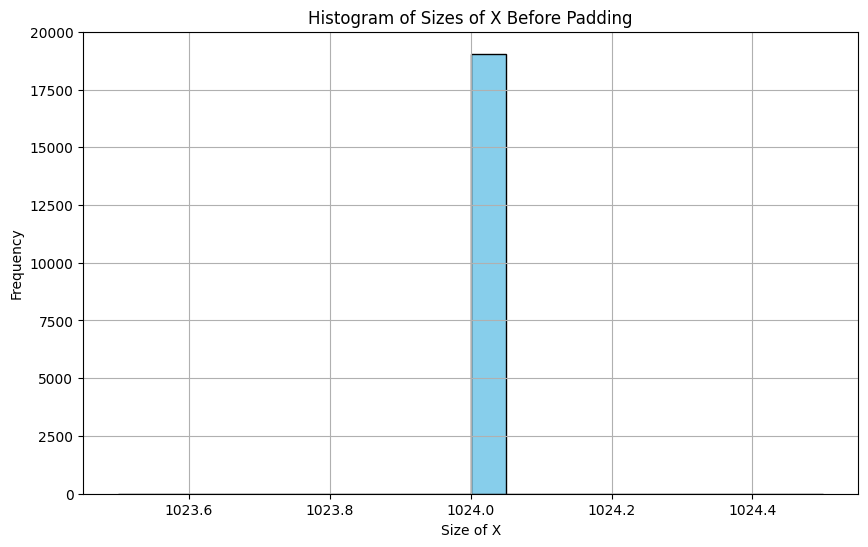

In [4]:
import matplotlib.pyplot as plt

# List to store sizes of X for each layer
sizes_before_padding = []

# Iterate through each layer
for layer_num in hubert_embeddings_df['Layer'].unique():
    # Clone the original DataFrame to preserve the original embeddings
    phonation_mode_df = hubert_embeddings_df[hubert_embeddings_df['Layer'] == layer_num].copy(deep=True)
    # Extract embeddings for the current layer
    sizes_before_padding.extend([len(embedding) for embedding in phonation_mode_df['Embedding']])

# Plotting histogram
plt.figure(figsize=(10, 6))
plt.hist(sizes_before_padding, bins=20, color='skyblue', edgecolor='black')
plt.title('Histogram of Sizes of X Before Padding')
plt.xlabel('Size of X')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()
